In [1]:
# %% load environment
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
from pathlib import Path
from torch.utils.data import DataLoader

join = os.path.join
import torch

from skimage import io, transform
import torch.nn.functional as F

from pytorch_ood.detector import Mahalanobis
from pytorch_ood.utils import OODMetrics

import monai
from monai.metrics import DiceMetric

from PIL import Image



from utils.util_swinlitemedsam import ( 
    MedSAM_Lite,
    resize_longest_side,
    pad_image,
    MedSAM_infer_npz_2D,
    resize_box_to_256,
    get_points_256,
    get_scribble_256,
    medsam_inference
)


from models import (PromptEncoder, TwoWayTransformer, SwinTransformer, MaskDecoder_Prompt)

PROJECT_ROOT="/export/home/rstanciu/FM_thesis_Razvan/FM_thesis/"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))


from utils.dep_injection_util import (
        BaseDataset,
        BBoxFromMask,
        NpzLoader,
        PngLoader
)

/export/home/rstanciu/FM_thesis_Razvan/FM_thesis/.venv/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
import numpy as np
from monai.transforms import MapTransform

class RepeatChannelNumpyd(MapTransform):
    def __init__(self, keys, repeats=3, to_channel_last=True):
        super().__init__(keys)
        self.repeats = repeats
        self.to_channel_last = to_channel_last

    def __call__(self, data):
        d = dict(data)

        for key in self.keys:
            x = d[key]

            # Ensure channel-first
            if x.ndim == 2:
                x = x[None, ...]  # (H, W) -> (1, H, W)

            # Repeat channels if needed
            if x.shape[0] == 1:
                x = np.repeat(x, self.repeats, axis=0)  # (C, H, W)

            # Convert to channel-last if requested
            if self.to_channel_last:
                x = np.transpose(x, (2, 1, 0))  # (H, W, C)

            d[key] = x.astype(np.uint8, copy=False)

        return d
    

    

class CropByBBoxd(MapTransform):
    def __init__(self, keys, bbox_key="bbox", padding=0):
        super().__init__(keys)
        self.bbox_key = bbox_key
        self.padding = padding

    def __call__(self, data):
        d = dict(data)

        bbox = d[self.bbox_key]
        if isinstance(bbox, list):
            bbox = bbox[0]

        x_min, y_min, x_max, y_max = bbox.astype(int)

        # assume image/mask are H x W or H x W x C
        ref = d[self.keys[0]]
        H, W = ref.shape[:2]

        x_min = max(0, x_min - self.padding)
        y_min = max(0, y_min - self.padding)
        x_max = min(W, x_max + self.padding)
        y_max = min(H, y_max + self.padding)

        for key in self.keys:
            x = d[key]

            if x.ndim == 2:
                d[key] = x[y_min:y_max, x_min:x_max]
            elif x.ndim == 3:
                d[key] = x[y_min:y_max, x_min:x_max, :]
            else:
                raise ValueError(f"Unsupported shape for {key}: {x.shape}")

        d["crop_bbox"] = np.array([x_min, y_min, x_max, y_max], dtype=np.int32)

        # adjust bbox to cropped space
        new_bbox = np.array([
            bbox[0] - x_min,
            bbox[1] - y_min,
            bbox[2] - x_min,
            bbox[3] - y_min,
        ], dtype=np.int32)

        d["bbox"] = [new_bbox]

        return d    




data_transform=monai.transforms.Compose([
                    RepeatChannelNumpyd(keys=["image"], repeats=3, to_channel_last=False),
                    #CropByBBoxd(keys=["image", "mask"], bbox_key="bbox", padding=20)
                    #monai.transforms.EnsureChannelFirstd(keys=['image', 'mask'], channel_dim="no_channel"),
                    # monai.transforms.RandFlipd(keys=['img', 'mask'], prob=1, spatial_axis=1),
                    # monai.transforms.RandRotated(keys=['img', 'mask'], range_x=np.pi/4, prob=1, mode=['bilinear', 'nearest'])
                    ])

In [3]:
csv_path="/mnt/data/spathak/CLaM-Annot-metadata.csv"

df=pd.read_csv(csv_path, delimiter=";")
df['AbnormalityType']=df['AbnormalityType'].fillna("None")
df['ImagePath']=df['ImagePath'].fillna("None")
df['ROIPath']=df['ROIPath'].fillna("None")

df_masses=df[df['AbnormalityType']=="Mass"].reset_index()
df_no_masses=df[df['AbnormalityType']!="Mass"].reset_index()

In [4]:
root="/mnt/data/spathak"


def collect_ZGT_files(root, metadata_df):
    root = Path(root)

    samples = []
    for row in metadata_df.itertuples():
        image_file= root / Path(row.ImagePath)
        mask_file=  root / Path(row.ROIPath) if Path(row.ROIPath).name != "None" else None

        samples.append({
            "image_path": image_file,
            "mask_path": mask_file,
        })  

    return samples

In [8]:
img_path=df_masses['ImagePath'][0]

sample_path= root / Path(img_path)

loader = PngLoader(dtype=np.uint8)

img=loader(sample_path)

img.shape

(2921, 1283, 3)

In [5]:
test_df=pd.read_pickle("./test_ZGT.pkl")

In [6]:
loader = PngLoader(dtype=np.uint8)

bbox_generator = BBoxFromMask(
    annotation_threshold=0.5,
    bbox_padding=0,
    allow_empty_mask=True
)


id_dataset = BaseDataset(
    root=root,
    format_loader=loader,
    file_collector=collect_ZGT_files,
    collector_kwargs={"metadata_df": test_df},
    transforms=data_transform,
    bbox_generator=bbox_generator
)

ood_dataset = BaseDataset(
    root=root,
    format_loader=loader,
    file_collector=collect_ZGT_files,
    collector_kwargs={"metadata_df": df_no_masses},
    transforms=data_transform,
    bbox_generator=bbox_generator,
    label=-1
)


In [8]:
ood_dataset[49]["label"]

tensor(-1)

In [7]:
device="cpu"
lite_medsam_checkpoint_path="/export/home/rstanciu/Downloads/Swin_LiteMedSAM.pth"
few_shot_checkpoint="/export/home/rstanciu/FM_thesis_Razvan/FM_thesis/Swin_LiteMedSAM/work_dir/Swin_LiteMedSAM-20260510-1212/medsam_lite_best.pth"

medsam_lite_image_encoder = SwinTransformer()

medsam_lite_prompt_encoder = PromptEncoder(embed_dim=256,
                                           image_embedding_size=(64, 64),
                                           input_image_size=(256, 256),
                                           mask_in_chans=16)

medsam_lite_mask_decoder = MaskDecoder_Prompt(
    num_multimask_outputs=3,
    transformer=TwoWayTransformer(
        depth=2,
        embedding_dim=256,
        mlp_dim=2048,
        num_heads=8,
    ),
    transformer_dim=256,
    iou_head_depth=3,
    iou_head_hidden_dim=256,
)

medsam_lite_model = MedSAM_Lite(image_encoder=medsam_lite_image_encoder,
                                mask_decoder=medsam_lite_mask_decoder,
                                prompt_encoder=medsam_lite_prompt_encoder)

lite_medsam_checkpoint = torch.load(few_shot_checkpoint,
                                    map_location='cpu')
try:
    medsam_lite_model.load_state_dict(lite_medsam_checkpoint)
except:
    try:
        medsam_lite_model.load_state_dict(lite_medsam_checkpoint['model'])
    except Exception as e:
        print(e)
        raise ValueError("Failed to load the checkpoint")

medsam_lite_model.to(device)
medsam_lite_model.eval()

MedSAM_Lite(
  (image_encoder): SwinTransformer(
    (patch_embed): PatchEmbed(
      (seq): Sequential(
        (0): Conv2d_BN(
          (c): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): GELU(approximate='none')
        (2): Conv2d_BN(
          (c): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
    )
    (stage1): BasicLayer(
      (downsample): PatchMerging(
        (patch_merge): Unfold(kernel_size=2, dilation=1, padding=0, stride=2)
        (linear): Linear(in_features=256, out_features=128, bias=True)
      )
      (blocks): ModuleList(
        (0): ModuleList(
          (0): SwinBlock(
            (attention_block): Residual(
              (fn): PreNorm(
                (norm): LayerNorm((128,), eps=1e-05, elementwise

### OOD detection

In [11]:
# Pass ID data through encoder and fit Mahalanobis distance metric
feats_list_id = []
labels_list_id = []


def preprocess_img(img, device):
    img=resize_longest_side(img,256)
    img=(img - img.min()) / np.clip(
        img.max() - img.min(), a_min=1e-8, a_max=None)
    img=pad_image(img, 256)
    img=torch.tensor(img).float().permute(
        2, 0, 1).unsqueeze(0).to(device)
    return img
    



with torch.no_grad():
    for sample in id_dataset:
        
        img = sample["image"]    
        img= preprocess_img(img,device)
        
        y = sample["label"].to(device).long()
        
        
        
        
        z, _ = medsam_lite_model.image_encoder(img)              # [B, C, H, W] feature maps
        z = z.mean(dim=(2, 3))                     # [B, C] global average pool

        feats_list_id.append(z)
        labels_list_id.append(y)

Z_id = torch.cat(feats_list_id, dim=0)
Y_id = torch.stack(labels_list_id, dim=0)

detector = Mahalanobis(model=None)
detector.fit_features(Z_id, Y_id)

In [12]:
# Predict on OOD dataset
feats_list_ood = []

with torch.no_grad():
    for sample in ood_dataset:
        img = sample["image"]
        img= preprocess_img(img,device)
        z,_ = medsam_lite_model.image_encoder(img)
        z = z.mean(dim=(2, 3))
        feats_list_ood.append(z)

Z_ood = torch.cat(feats_list_ood, dim=0)


scores_id = detector.predict_features(Z_id)
scores_ood = detector.predict_features(Z_ood)

In [13]:
torch.save(Z_id, "/export/home/rstanciu/FM_thesis_Razvan/FM_thesis/feature_space_inspection/SwinLiteMedSAM-fewshot_ZGT_MDS_features")

In [14]:
# 1) Make label tensors (same length as scores)
y_id  = torch.zeros(len(scores_id), dtype=torch.long)        # ID label = 0
y_ood = -torch.ones(len(scores_ood), dtype=torch.long)       # OOD label = -1

# 2) Concatenate
scores = torch.cat([scores_id.detach().cpu(), scores_ood.detach().cpu()], dim=0)
y_true = torch.cat([y_id, y_ood], dim=0)

# 3) Compute metrics
metrics = OODMetrics()
metrics.update(scores, y_true)
result = metrics.compute()

print(result)

{'AUROC': 0.9811206459999084, 'AUTC': 0.37962213158607483, 'AUPR-IN': 0.8442504405975342, 'AUPR-OUT': 0.9970346689224243, 'FPR95TPR': 0.0}


### Segmentation

In [8]:
pred_masks_metrics = []

dice_metric = DiceMetric(
    include_background=True,
    reduction="mean"
)


for i, sample in enumerate(id_dataset):
        
    sample_gt = sample["mask"]
    
    # # skip if mask is empty
    # if np.sum(sample_gt) == 0:
    #     continue

    pred_mask, iou = MedSAM_infer_npz_2D(
        sample,
        device=device,
        medsam_lite_model=medsam_lite_model
    )

    pred = torch.from_numpy(pred_mask).unsqueeze(0).unsqueeze(0)
    gt = torch.from_numpy(sample_gt).unsqueeze(0).unsqueeze(0)

    pred = (pred > 0).float()
    gt = (gt > 0).float()

    dice = dice_metric(y_pred=pred, y=gt)

    pred_masks_metrics.append((sample_gt, pred_mask, dice.item(), iou))

box:[  48. 1781.  329. 2047.]
box256 shape: (4,)
box:[ 256.  806.  962. 1423.]
box256 shape: (4,)
box:[ 843. 2145. 1054. 2408.]
box256 shape: (4,)
box:[ 650. 1024. 1033. 1413.]
box256 shape: (4,)
box:[208. 731. 306. 822.]
box256 shape: (4,)
box:[1142. 1620. 1326. 1822.]
box256 shape: (4,)
box:[ 475. 2013.  991. 2536.]
box256 shape: (4,)
box:[ 893. 1000. 1120. 1203.]
box256 shape: (4,)
box:[ 632. 1444.  758. 1551.]
box256 shape: (4,)
box:[ 594.  893.  726. 1065.]
box256 shape: (4,)
box:[1146.  950. 1601. 1485.]
box256 shape: (4,)
box:[ 330. 1167.  509. 1325.]
box256 shape: (4,)
box:[  16.  849.  178. 1018.]
box256 shape: (4,)
box:[ 668. 2251. 1338. 2559.]
box256 shape: (4,)
box:[1012.  884. 1097.  977.]
box256 shape: (4,)
box:[ 814.  673. 1252.  944.]
box256 shape: (4,)
box:[ 902. 1753. 1135. 1947.]
box256 shape: (4,)
box:[1157. 2567. 1347. 2729.]
box256 shape: (4,)
box:[ 602.  778. 1078. 1052.]
box256 shape: (4,)
box:[ 225.  896. 1281. 1680.]
box256 shape: (4,)
box:[ 774. 1083.  920. 1

In [10]:
sum=0
ct=0

for idx, result in enumerate(pred_masks_metrics):
    sample_dice=pred_masks_metrics[idx][-2]
    print(f"{idx}:{sample_dice}")
    sum+=sample_dice
    ct+=1
avg_dice=sum/ct
print(avg_dice)




0:0.8525860905647278
1:0.7741926312446594
2:0.7903249263763428
3:0.7278040051460266
4:0.8037262558937073
5:0.9056711196899414
6:0.9404422640800476
7:0.9450530409812927
8:0.5783901214599609
9:0.8348593711853027
10:0.7385660409927368
11:0.8761047124862671
12:0.7995311617851257
13:0.3077499270439148
14:0.8583250641822815
15:0.8565270900726318
16:0.9155359864234924
17:0.7571556568145752
18:0.7315952181816101
19:0.9320821762084961
20:0.820712685585022
21:0.8288193345069885
22:0.8488830924034119
23:0.8388594388961792
24:0.8506476879119873
25:0.7753908634185791
26:0.8421387672424316
27:0.7521004676818848
28:0.8640493154525757
29:0.7303427457809448
30:0.8287133574485779
31:0.7957244515419006
32:0.505577564239502
33:0.5983762145042419
34:0.8539847731590271
35:0.863257884979248
36:0.6958208084106445
37:0.8760730624198914
38:0.06452471017837524
39:0.7205001711845398
40:0.8700947761535645
41:0.8995741605758667
42:0.8217492699623108
43:0.786716639995575
44:0.936891496181488
45:0.6050061583518982
46

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


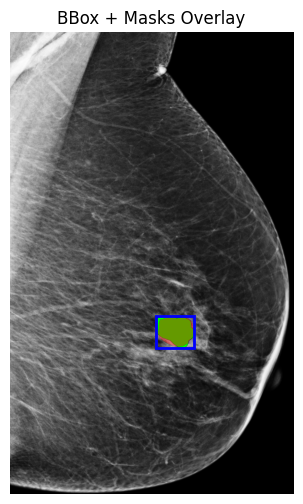

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def show_bbox_overlay(image, bbox, gt_mask=None, pred_mask=None):
    """
    Overlay bbox (+ optional masks) on an image.

    bbox: np.array([x_min, y_min, x_max, y_max])
    """

    fig, ax = plt.subplots(1, figsize=(6, 6))

    # Show image (if provided)
    if image is not None:
        ax.imshow(image, cmap="gray")

    # Optional: GT mask (green)
    if gt_mask is not None:
        gt = np.zeros((*gt_mask.shape, 4))
        gt[..., 1] = gt_mask
        gt[..., 3] = gt_mask * 0.4
        ax.imshow(gt)

    # Optional: Pred mask (red)
    if pred_mask is not None:
        pred = np.zeros((*pred_mask.shape, 4))
        pred[..., 0] = pred_mask
        pred[..., 3] = pred_mask * 0.4
        ax.imshow(pred)

    # Draw bbox
    x_min, y_min, x_max, y_max = bbox[0]
    width = x_max - x_min
    height = y_max - y_min

    rect = patches.Rectangle(
        (x_min, y_min),
        width,
        height,
        linewidth=2,
        edgecolor="blue",
        facecolor="none"
    )

    ax.add_patch(rect)

    ax.set_title("BBox + Masks Overlay")
    ax.axis("off")
    plt.show()

idx=16
sample=id_dataset[idx]
    
img=sample["image"]
bbox=sample["bbox"]
gt_mask_sample = sample["mask"]
pred_mask_sample = pred_masks_metrics[idx][1]



show_bbox_overlay(
    image=img,           # or your original image if you have it
    bbox=bbox,
    gt_mask=gt_mask_sample,
    pred_mask=pred_mask_sample
)


